# Neural Networks for Biomedical Applications — Tutorial Notebook

This notebook covers the core deep learning concepts from the AI for Medicine course,
illustrated with **biomedical datasets**.

**Topics covered:**
1. Neural Network Fundamentals (activation functions, cross-entropy)
2. Regularization (Dropout, Batch Normalization, Weight Decay)
3. Convolutional Neural Networks (CNNs)
4. Residual Networks (ResNet & skip connections)
5. Training Workflow & Common Pitfalls
6. Fine-tuning Pre-trained Models

**Biomedical datasets used:**
- **Wisconsin Breast Cancer** (sklearn) — 30 clinical features, classify tumor as malignant vs benign
- **Synthetic cell microscopy images** — grayscale images of cell nuclei generated to mimic histopathology slides

---
> **Prerequisites:** basic Python, NumPy, and the optimization notebook.

In [1]:
# ---- Imports ----
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 11
torch.manual_seed(42)
np.random.seed(42)

print('PyTorch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

PyTorch version: 2.10.0+cu128
Using device: cuda


---
## Dataset 1 — Wisconsin Breast Cancer

30 features extracted from digitized images of fine needle aspirate (FNA) of breast masses.
Each sample is labelled **0 = malignant** or **1 = benign**.

Features include: radius, texture, perimeter, area, smoothness, compactness, concavity, etc.
of the cell nuclei present in each image.

In [2]:
# Load and explore the breast cancer dataset
data = load_breast_cancer()
X_raw, y_raw = data.data, data.target

print(f'Samples: {X_raw.shape[0]},  Features: {X_raw.shape[1]}')
print(f'Classes: {data.target_names}  (0=malignant, 1=benign)')
print(f'Class balance — malignant: {(y_raw==0).sum()}, benign: {(y_raw==1).sum()}')
print(f'\nFirst 5 feature names: {data.feature_names[:5]}')

Samples: 569,  Features: 30
Classes: ['malignant' 'benign']  (0=malignant, 1=benign)
Class balance — malignant: 212, benign: 357

First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


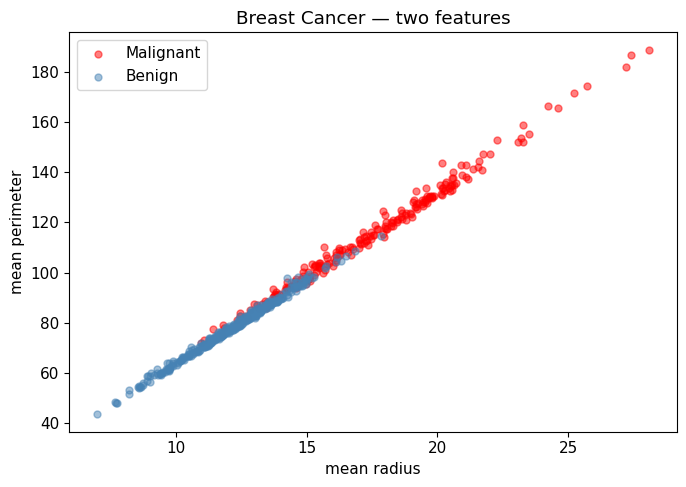

In [3]:
# Visualise two discriminative features
feat_x, feat_y = 0, 2   # 'mean radius' vs 'mean perimeter'
colors = ['red', 'steelblue']
labels = ['Malignant', 'Benign']

plt.figure(figsize=(7, 5))
for cls in [0, 1]:
    mask = y_raw == cls
    plt.scatter(X_raw[mask, feat_x], X_raw[mask, feat_y],
                c=colors[cls], label=labels[cls], alpha=0.5, s=25)
plt.xlabel(data.feature_names[feat_x])
plt.ylabel(data.feature_names[feat_y])
plt.title('Breast Cancer — two features')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Preprocess: standardise features (mean=0, std=1)
# Neural networks train much better on normalised inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(f'Train: {X_train_t.shape},  Test: {X_test_t.shape}')

# --- PyTorch Dataset & DataLoader ---
class CancerDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(CancerDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(CancerDataset(X_test_t,  y_test_t),  batch_size=32)

Train: torch.Size([455, 30]),  Test: torch.Size([114, 30])


---
## Part 1 — Neural Network Fundamentals

### 1.1 Activation Functions

Without an activation function, stacking linear layers would still be a linear model.
Activations introduce **non-linearity**, letting the network learn complex patterns.

| Function | Formula | Pros / Cons |
|---|---|---|
| Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | Output in (0,1); vanishing gradient for large \|x\| |
| Tanh | $\tanh(x)$ | Output in (-1,1); still vanishes |
| **ReLU** | $\max(0, x)$ | No vanishing gradient; most widely used |
| Leaky ReLU | $\max(0.01x, x)$ | Fixes "dead neuron" problem of ReLU |

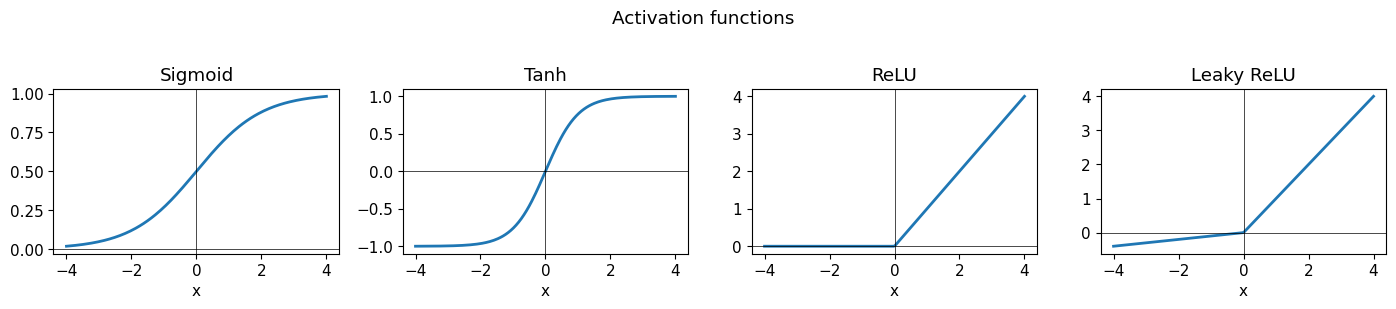

In [5]:
x = torch.linspace(-4, 4, 200)

activations = {
    'Sigmoid':     torch.sigmoid(x),
    'Tanh':        torch.tanh(x),
    'ReLU':        F.relu(x),
    'Leaky ReLU':  F.leaky_relu(x, 0.1),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x.numpy(), y.numpy(), linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(name)
    ax.set_xlabel('x')
plt.suptitle('Activation functions', y=1.02)
plt.tight_layout()
plt.savefig('activations.png', dpi=100)
plt.show()

### 1.2 Building a Multi-Layer Neural Network

A **multi-layer perceptron (MLP)** stacks linear layers with activations:

$$H^{(1)} = \text{ReLU}(W^{(1)}X + b^{(1)})$$
$$H^{(2)} = \text{ReLU}(W^{(2)}H^{(1)} + b^{(2)})$$
$$\hat{Y} = W^{(3)}H^{(2)} + b^{(3)} \quad\text{(logits)}$$

The final layer outputs **logits** (raw scores). `nn.CrossEntropyLoss` applies softmax internally.

In [6]:
# ---- Simple MLP for cancer classification ----

class CancerMLP(nn.Module):
    def __init__(self, in_features, hidden_sizes, n_classes):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, n_classes))  # output logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)   # raw logits — DO NOT apply softmax here!

model = CancerMLP(in_features=30, hidden_sizes=[64, 32], n_classes=2)
print(model)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params}')

CancerMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total parameters: 4130


### 1.3 Cross-Entropy Loss

For classification, we use cross-entropy loss:

$$\mathcal{L}(Y, \hat{Y}) = -\sum_j Y_j \log \hat{Y}_j$$

where $\hat{Y} = \text{softmax}(\text{logits})$.

**Important pitfall:** `nn.CrossEntropyLoss` expects **raw logits**, not softmax probabilities.
It also expects targets as **integer class indices** (not one-hot vectors).

In [7]:
# Verify correct loss at random initialisation
# For 2 balanced classes, expected loss = -log(1/2) ≈ 0.693

torch.manual_seed(0)
test_model  = CancerMLP(30, [64, 32], 2)
loss_fn     = nn.CrossEntropyLoss()

with torch.no_grad():
    logits = test_model(X_train_t[:100])
    loss   = loss_fn(logits, y_train_t[:100])

print(f'Loss at random init:    {loss.item():.4f}')
print(f'Expected (random guess): {-np.log(0.5):.4f}')
print('\nGood! The initial loss is close to the expected value.')

Loss at random init:    0.6862
Expected (random guess): 0.6931

Good! The initial loss is close to the expected value.


In [8]:
# ---- Training helper functions ----

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()                         # activate training mode (affects dropout/BN)
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()             # 1. clear gradients
        logits = model(X_batch)           # 2. forward pass
        loss   = loss_fn(logits, y_batch) # 3. compute loss
        loss.backward()                   # 4. backpropagation
        optimizer.step()                  # 5. update parameters

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()                          # deactivate dropout/BN
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits     = model(X_batch)
        total_loss += loss_fn(logits, y_batch).item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def train_model(model, train_loader, test_loader, n_epochs=60, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn   = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(n_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        te_loss, te_acc = evaluate(model, test_loader, loss_fn, device)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

    return history


def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['test_loss'],  label='Test')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['test_acc'],  label='Test')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy'); axes[1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

print('Helper functions defined.')

Helper functions defined.


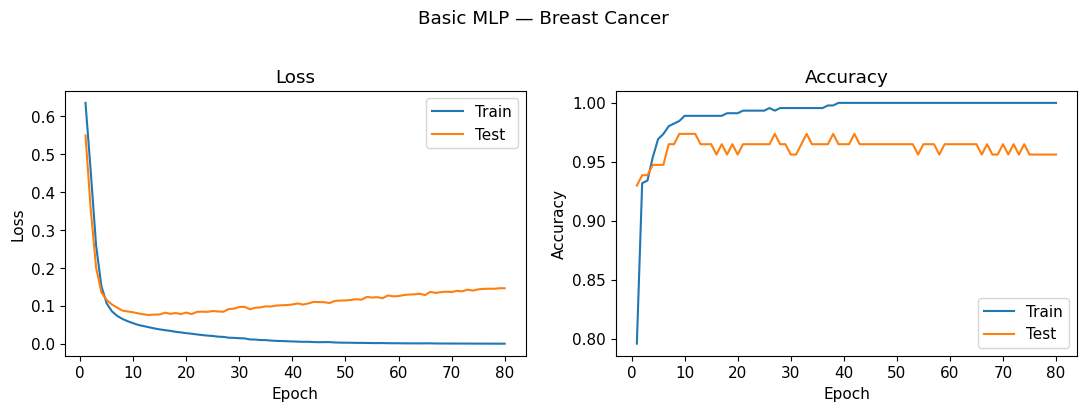

Final test accuracy: 95.6%


In [9]:
# Train a basic MLP
torch.manual_seed(42)
mlp = CancerMLP(30, [64, 32], 2)
history_mlp = train_model(mlp, train_loader, test_loader, n_epochs=80)
plot_history(history_mlp, 'Basic MLP — Breast Cancer')

final_acc = history_mlp['test_acc'][-1]
print(f'Final test accuracy: {final_acc*100:.1f}%')

---
## Part 2 — Regularization

Medical datasets are often **small**. Without regularization, a large network easily memorizes the training set (overfitting) and generalizes poorly to new patients.

### Three main techniques:

| Technique | What it does | Effect |
|---|---|---|
| **Weight Decay (L2)** | Penalizes large weights in the loss | Prefers simpler models |
| **Dropout** | Randomly zeros neurons during training | Forces redundant representations |
| **Batch Normalization** | Normalizes layer inputs per mini-batch | Stabilizes and accelerates training |

### 2.1 Deliberately Overfitting a Small Dataset

First, let's reproduce the overfitting problem with a large model on only 80 samples.

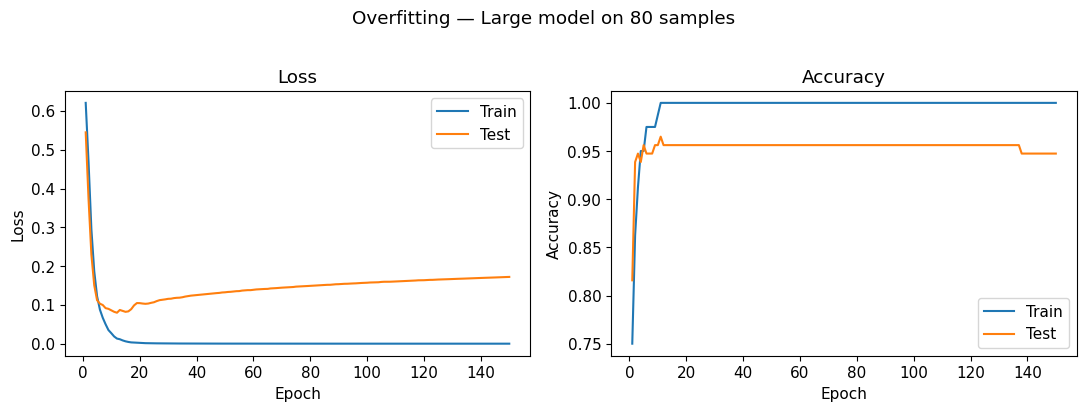

Notice: train accuracy → 100%, test accuracy is lower → overfitting!


In [10]:
# Use a very small subset to trigger overfitting
small_X = X_train_t[:80]
small_y = y_train_t[:80]

small_train = DataLoader(CancerDataset(small_X, small_y), batch_size=16, shuffle=True)

torch.manual_seed(42)
big_model = CancerMLP(30, [256, 128, 64], 2)   # deliberately large
history_overfit = train_model(big_model, small_train, test_loader, n_epochs=150)
plot_history(history_overfit, 'Overfitting — Large model on 80 samples')
print('Notice: train accuracy → 100%, test accuracy is lower → overfitting!')

### 2.2 Dropout

During training, Dropout **randomly sets neuron outputs to 0** with probability $1-p$.
At test time, all neurons are active and outputs are scaled by $p$.

$$y = \frac{m \odot a}{p}, \quad m_i \sim \text{Bernoulli}(p)$$

**Critical pitfalls:**
- Always use `nn.Dropout()` in your model definition (not `F.dropout()` in `forward`)
- Always call `model.train()` / `model.eval()` — dropout is OFF during eval

In [11]:
class CancerMLPRegularized(nn.Module):
    def __init__(self, in_features, hidden_sizes, n_classes, dropout_p=0.3, use_bn=True):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))  # normalise before activation
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_p)) # dropout AFTER activation
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

print('CancerMLPRegularized defined.')
print('Components: Linear → BatchNorm → ReLU → Dropout → ... → Linear')

CancerMLPRegularized defined.
Components: Linear → BatchNorm → ReLU → Dropout → ... → Linear


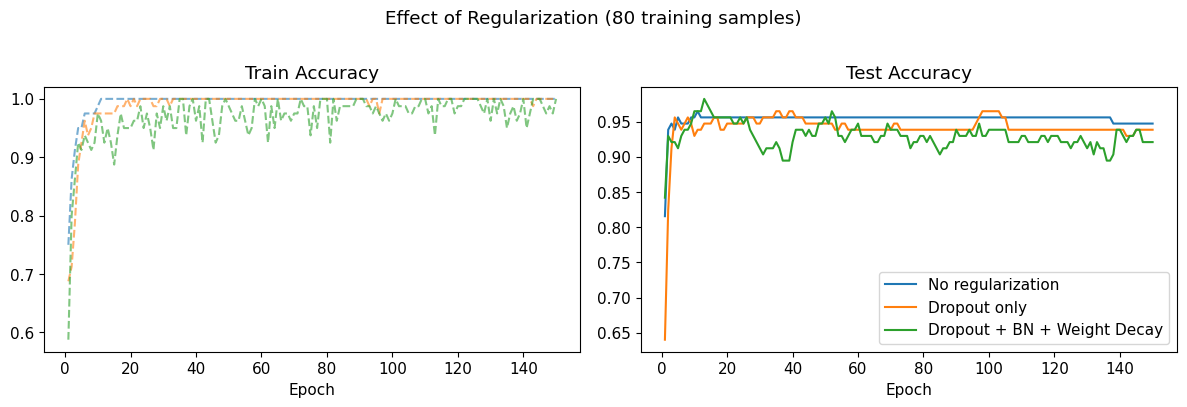

In [12]:
# Compare: no regularisation vs dropout+BN vs weight decay+dropout+BN

torch.manual_seed(42)
m_no_reg = CancerMLP(30, [256, 128, 64], 2)
hist_no_reg = train_model(m_no_reg, small_train, test_loader, n_epochs=150)

torch.manual_seed(42)
m_dropout = CancerMLPRegularized(30, [256, 128, 64], 2, dropout_p=0.4, use_bn=False)
hist_dropout = train_model(m_dropout, small_train, test_loader, n_epochs=150)

torch.manual_seed(42)
m_full_reg = CancerMLPRegularized(30, [256, 128, 64], 2, dropout_p=0.4, use_bn=True)
hist_full = train_model(m_full_reg, small_train, test_loader,
                        n_epochs=150, weight_decay=1e-4)

epochs = range(1, 151)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, label in [
    (hist_no_reg,  'No regularization'),
    (hist_dropout, 'Dropout only'),
    (hist_full,    'Dropout + BN + Weight Decay'),
]:
    axes[0].plot(epochs, hist['train_acc'], '--', alpha=0.6)
    axes[1].plot(epochs, hist['test_acc'],        label=label)

axes[0].set_title('Train Accuracy'); axes[0].set_xlabel('Epoch')
axes[1].set_title('Test Accuracy');  axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.suptitle('Effect of Regularization (80 training samples)', y=1.01)
plt.tight_layout()
plt.savefig('regularization.png', dpi=100)
plt.show()

### 2.3 Batch Normalization

After each linear layer, BatchNorm standardizes the activations across the mini-batch:

$$\text{BN}(x) = \gamma \odot \frac{x - \hat{\mu}_B}{\sqrt{\hat{\sigma}_B^2 + \varepsilon}} + \beta$$

- $\hat{\mu}_B, \hat{\sigma}_B^2$ — batch mean and variance (computed during training; running statistics used at test time)
- $\gamma, \beta$ — **learnable** scale and shift parameters

Benefits: faster training, less sensitive to learning rate, mild regularization.

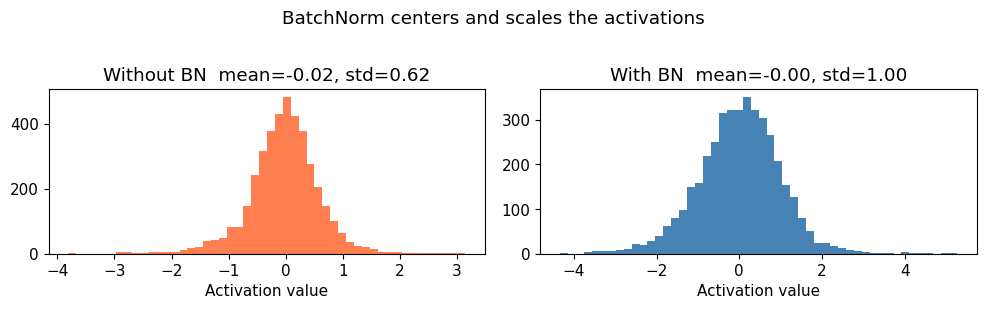

In [13]:
# Demonstrate BatchNorm effect on layer activations
torch.manual_seed(5)
layer  = nn.Linear(30, 64)
bn     = nn.BatchNorm1d(64)

with torch.no_grad():
    h_raw = layer(X_train_t[:64])          # activations WITHOUT BatchNorm
    h_bn  = bn(h_raw)                      # activations WITH BatchNorm

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(h_raw.numpy().flatten(), bins=50, color='coral')
axes[0].set_title(f'Without BN  mean={h_raw.mean():.2f}, std={h_raw.std():.2f}')
axes[1].hist(h_bn.numpy().flatten(),  bins=50, color='steelblue')
axes[1].set_title(f'With BN  mean={h_bn.mean():.2f}, std={h_bn.std():.2f}')
for ax in axes: ax.set_xlabel('Activation value')
plt.suptitle('BatchNorm centers and scales the activations', y=1.02)
plt.tight_layout()
plt.show()

---
## Dataset 2 — Synthetic Cell Microscopy Images

We generate grayscale 32×32 images simulating histopathology slides:
- **Benign cells**: small, round, uniformly bright nuclei — low variance in size/shape
- **Malignant cells**: large, irregular, variable nuclei — high variance, darker background

This is a simplified visual analogy of how pathologists distinguish cancer cells under a microscope.

Dataset shape: (800, 1, 32, 32),  labels: (800,)
Malignant: 400,  Benign: 400


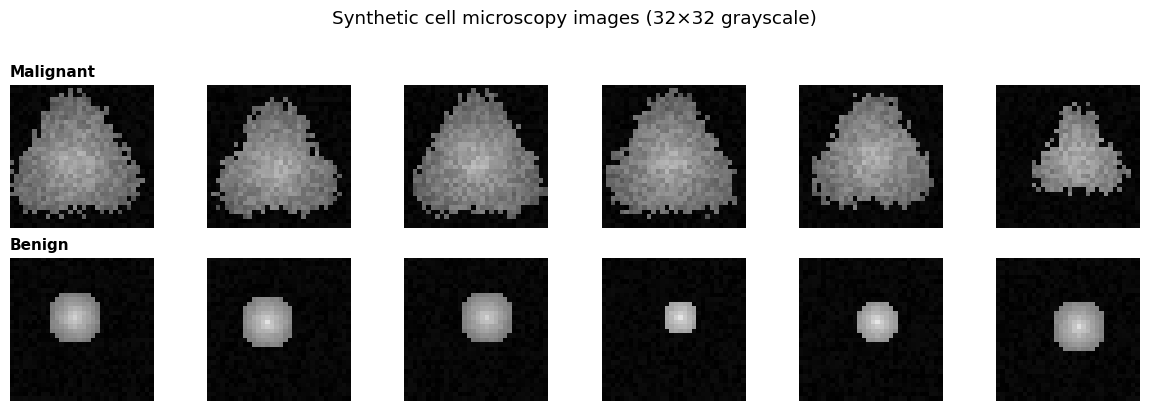

In [14]:
def make_cell_image(label, img_size=32, seed=None):
    """
    Generate a synthetic grayscale cell image.
    label=0: malignant — large, irregular nucleus
    label=1: benign  — small, round nucleus
    """
    rng = np.random.RandomState(seed)
    img = np.zeros((img_size, img_size), dtype=np.float32)
    cx, cy = img_size // 2 + rng.randint(-3, 3), img_size // 2 + rng.randint(-3, 3)

    if label == 1:    # benign: small, round, bright
        radius = rng.randint(4, 7)
        intensity = 0.85 + rng.uniform(-0.05, 0.05)
        for i in range(img_size):
            for j in range(img_size):
                d = np.sqrt((i - cx)**2 + (j - cy)**2)
                if d < radius:
                    img[i, j] = intensity * np.exp(-0.1 * d)
    else:             # malignant: large, irregular, variable
        radius = rng.randint(9, 14)
        for i in range(img_size):
            for j in range(img_size):
                # irregular shape via angular perturbation
                angle     = np.arctan2(i - cx, j - cy)
                r_jagged  = radius + 2.5 * np.sin(3 * angle) + rng.uniform(-1.5, 1.5)
                d         = np.sqrt((i - cx)**2 + (j - cy)**2)
                if d < r_jagged:
                    img[i, j] = 0.6 * np.exp(-0.05 * d) + rng.uniform(0, 0.15)

    # Add background noise
    img += rng.uniform(0, 0.05, size=img.shape)
    return np.clip(img, 0, 1)


def make_cell_dataset(n_per_class=400, img_size=32, seed=0):
    rng = np.random.RandomState(seed)
    images, labels = [], []
    for cls in [0, 1]:
        seeds = rng.randint(0, 99999, size=n_per_class)
        for s in seeds:
            images.append(make_cell_image(cls, img_size, seed=s))
            labels.append(cls)
    images = np.stack(images)[:, np.newaxis, :, :]  # shape: (N, 1, H, W)
    labels = np.array(labels)
    idx    = rng.permutation(len(labels))
    return images[idx], labels[idx]


images, labels = make_cell_dataset(n_per_class=400, img_size=32)
print(f'Dataset shape: {images.shape},  labels: {labels.shape}')
print(f'Malignant: {(labels==0).sum()},  Benign: {(labels==1).sum()}')

# Preview
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for cls, row_axes, cname in zip([0, 1], axes, ['Malignant', 'Benign']):
    idxs = np.where(labels == cls)[0][:6]
    for ax, i in zip(row_axes, idxs):
        ax.imshow(images[i, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    row_axes[0].set_title(cname, loc='left', fontsize=11, fontweight='bold')
plt.suptitle('Synthetic cell microscopy images (32×32 grayscale)', y=1.02)
plt.tight_layout()
plt.savefig('cell_images.png', dpi=100)
plt.show()

In [15]:
# Build PyTorch dataset
class CellDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return self.images[i], self.labels[i]

n_total = len(labels)
n_train = int(0.8 * n_total)
cell_ds    = CellDataset(images, labels)
cell_train, cell_test = random_split(cell_ds, [n_train, n_total - n_train],
                                     generator=torch.Generator().manual_seed(42))

cell_train_loader = DataLoader(cell_train, batch_size=32, shuffle=True)
cell_test_loader  = DataLoader(cell_test,  batch_size=32)
print(f'Train: {len(cell_train)},  Test: {len(cell_test)}')

Train: 640,  Test: 160


---
## Part 3 — Convolutional Neural Networks (CNNs)

For image data, fully connected layers are impractical (a 224×224 image = 50,176 inputs per neuron!).
CNNs exploit **spatial locality** — nearby pixels are related — using **shared filters**.

### 3.1 How Convolution Works

A 2D convolution slides a small **kernel** (filter) across the image:

$$(I * K)(i,j) = \sum_m \sum_n I(i+m,\, j+n) \cdot K(m,n)$$

Output size formula:
$$\text{output size} = \left\lfloor \frac{\text{input} - \text{kernel} + 2 \times \text{padding}}{\text{stride}} \right\rfloor + 1$$

**Typical rule of thumb:** use odd kernel sizes (3, 5, 7) and padding = (kernel−1)/2 to preserve spatial dimensions.

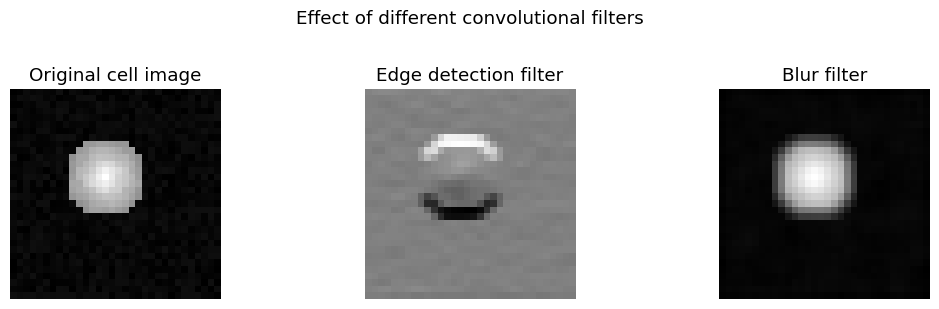

In a CNN, these filters are LEARNED from data, not hand-crafted.


In [16]:
# Visualise what a convolutional filter does to a cell image

sample_img = torch.tensor(images[0], dtype=torch.float32).unsqueeze(0)  # (1, 1, 32, 32)

# Define two interpretable filters manually
# Edge detector (horizontal Sobel)
edge_filter = torch.tensor([[[[-1., -2., -1.],
                               [ 0.,  0.,  0.],
                               [ 1.,  2.,  1.]]]])
# Gaussian blur
blur_filter = torch.ones(1, 1, 3, 3) / 9

with torch.no_grad():
    edge_out = F.conv2d(sample_img, edge_filter, padding=1)
    blur_out = F.conv2d(sample_img, blur_filter, padding=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].imshow(sample_img[0, 0].numpy(), cmap='gray'); axes[0].set_title('Original cell image')
axes[1].imshow(edge_out[0, 0].numpy(), cmap='gray');   axes[1].set_title('Edge detection filter')
axes[2].imshow(blur_out[0, 0].numpy(), cmap='gray');   axes[2].set_title('Blur filter')
for ax in axes: ax.axis('off')
plt.suptitle('Effect of different convolutional filters', y=1.02)
plt.tight_layout()
plt.savefig('conv_filters.png', dpi=100)
plt.show()
print('In a CNN, these filters are LEARNED from data, not hand-crafted.')

### 3.2 CNN Architecture

A typical CNN for image classification:

```
Input image
    ↓
[Conv → BN → ReLU → MaxPool] × n_blocks   ← feature extraction
    ↓
Flatten
    ↓
[Linear → ReLU → Dropout] × n_fc          ← classification head
    ↓
Output logits
```

In [17]:
class CellCNN(nn.Module):
    """Small CNN for binary cell classification."""

    def __init__(self, n_classes=2):
        super().__init__()
        # --- Feature extractor ---
        self.features = nn.Sequential(
            # Block 1: 1 → 16 channels, 32×32 → 16×16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # keep spatial size
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # halve spatial size

            # Block 2: 16 → 32 channels, 16×16 → 8×8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 32 → 64 channels, 8×8 → 4×4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # --- Classification head ---
        # After 3 MaxPool2d(2): 32 → 16 → 8 → 4, so feature map is 64 × 4 × 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


cnn = CellCNN()
# Trace the spatial dimensions manually
dummy = torch.zeros(1, 1, 32, 32)
with torch.no_grad():
    feat = cnn.features(dummy)
print(f'Feature map shape after extractor: {feat.shape}  (batch, channels, H, W)')
print(f'Total CNN parameters: {sum(p.numel() for p in cnn.parameters()):,}')

Feature map shape after extractor: torch.Size([1, 64, 4, 4])  (batch, channels, H, W)
Total CNN parameters: 154,978


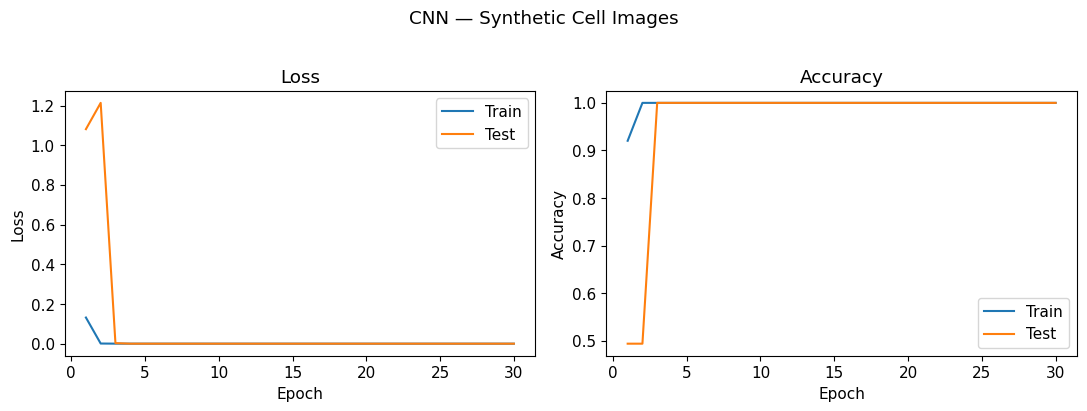

Final test accuracy: 100.0%


In [18]:
# Train the CNN
torch.manual_seed(42)
cnn = CellCNN().to(device)
history_cnn = train_model(cnn, cell_train_loader, cell_test_loader, n_epochs=30, lr=1e-3)
plot_history(history_cnn, 'CNN — Synthetic Cell Images')
print(f'Final test accuracy: {history_cnn["test_acc"][-1]*100:.1f}%')

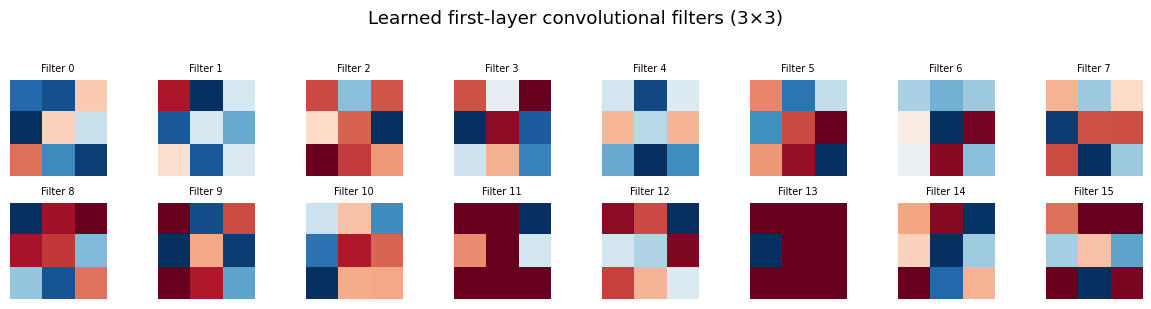

In [19]:
# Visualise what the CNN learned in its first-layer filters

filters = cnn.features[0].weight.detach().cpu()   # shape: (16, 1, 3, 3)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    f = filters[i, 0].numpy()
    ax.imshow(f, cmap='RdBu', vmin=-f.max(), vmax=f.max())
    ax.axis('off')
    ax.set_title(f'Filter {i}', fontsize=7)
plt.suptitle('Learned first-layer convolutional filters (3×3)', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 4 — Residual Networks (ResNet)

### The Degradation Problem

Naively adding more layers does **not** always help. Very deep networks suffer from the **vanishing gradient** problem — gradients shrink exponentially as they propagate back through many layers.

### Skip Connections (Shortcut Connections)

He et al. (2015) proposed adding a **skip connection** that bypasses each block:

$$H(x) = F(x) + x$$

The network now only needs to learn the **residual** $F(x) = H(x) - x$ (what to add to the input),
which is easier to learn than the full mapping $H(x)$.

In the extreme case, if $F(x) = 0$, the block becomes an identity — no harm done by adding depth.

In [20]:
class ResidualBlock(nn.Module):
    """One residual block: two conv layers + skip connection."""

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        # If dimensions differ (stride > 1 or channel change), project the skip connection
        self.skip = nn.Identity()  # default: identity
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = self.conv_path(x)   # F(x)
        out = out + self.skip(x)  # F(x) + x  ← the key skip connection
        return F.relu(out)


# Demo: gradient flows easily through a skip connection
block = ResidualBlock(16, 16)
x     = torch.randn(2, 16, 8, 8, requires_grad=True)
out   = block(x)
out.mean().backward()
print(f'Input gradient norm:  {x.grad.norm().item():.4f}  (would shrink without skip connection)')

Input gradient norm:  0.0186  (would shrink without skip connection)


MiniResNet parameters: 77,234


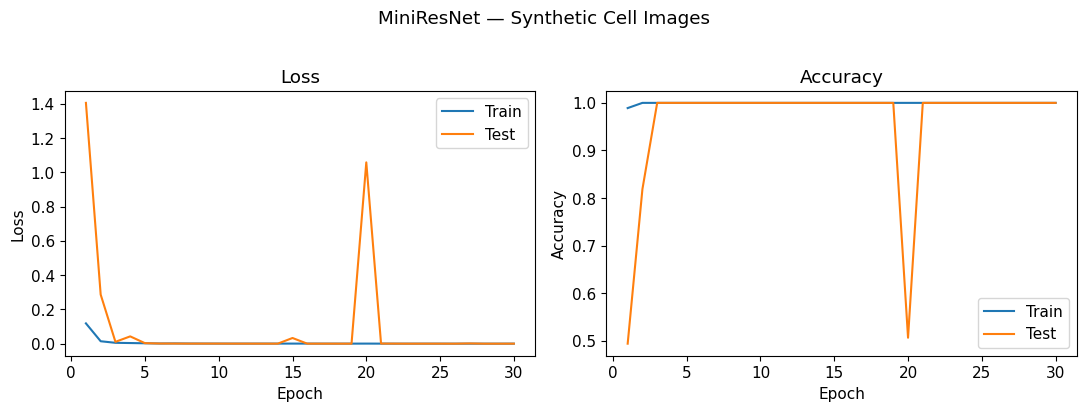

Final test accuracy: 100.0%


In [21]:
class MiniResNet(nn.Module):
    """Small ResNet adapted for 32×32 grayscale cell images."""

    def __init__(self, n_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.stage1 = ResidualBlock(16, 16)            # 32×32
        self.stage2 = ResidualBlock(16, 32, stride=2)  # 16×16
        self.stage3 = ResidualBlock(32, 64, stride=2)  # 8×8
        self.pool   = nn.AdaptiveAvgPool2d(1)          # global average pool → 1×1
        self.fc     = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)  # (batch, 64)
        return self.fc(x)


resnet = MiniResNet()
print(f'MiniResNet parameters: {sum(p.numel() for p in resnet.parameters()):,}')

torch.manual_seed(42)
resnet = MiniResNet().to(device)
history_resnet = train_model(resnet, cell_train_loader, cell_test_loader, n_epochs=30, lr=1e-3)
plot_history(history_resnet, 'MiniResNet — Synthetic Cell Images')
print(f'Final test accuracy: {history_resnet["test_acc"][-1]*100:.1f}%')

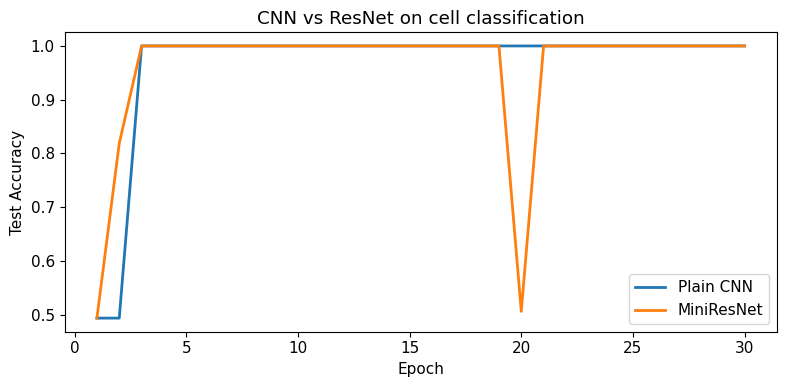

In [22]:
# Compare plain CNN vs ResNet
epochs = range(1, 31)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history_cnn['test_acc'],    label='Plain CNN',  linewidth=2)
plt.plot(epochs, history_resnet['test_acc'], label='MiniResNet', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.title('CNN vs ResNet on cell classification')
plt.legend()
plt.tight_layout()
plt.savefig('resnet_vs_cnn.png', dpi=100)
plt.show()

---
## Part 5 — Training Workflow & Common Pitfalls

Based on Andrej Karpathy's "recipe for training neural networks" — adapted for biomedical tasks.

### Step-by-step checklist

| Step | Goal | How |
|---|---|---|
| 1. Explore data | Understand your inputs | Visualize, check class balance, look for noise |
| 2. Sanity check loss | Verify initialisation | Initial loss ≈ -log(1/n_classes) |
| 3. Overfit one batch | Confirm training signal | Model should reach ≈100% on a tiny subset |
| 4. Regularize | Close train/test gap | Dropout, BN, weight decay, more data |
| 5. Tune LR | Most impactful hyperparameter | Try logarithmically spaced values |

### 5.1 Overfit One Batch (Sanity Check)

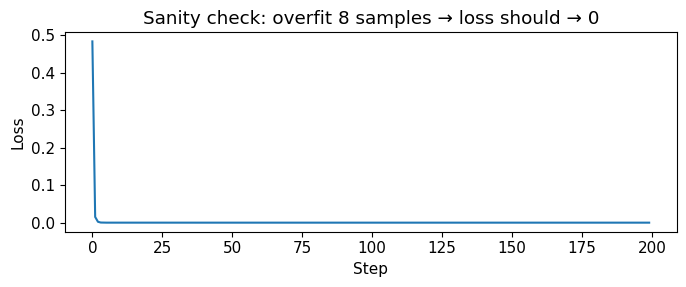

Final loss: 0.000000  — Model can memorize → training works correctly.


In [23]:
# A model that cannot memorize 8 samples has a bug!
torch.manual_seed(42)
sanity_model = CellCNN().to(device)
optimizer    = torch.optim.Adam(sanity_model.parameters(), lr=1e-3)
loss_fn      = nn.CrossEntropyLoss()

# Get exactly 8 training samples
X_tiny, y_tiny = next(iter(DataLoader(cell_train, batch_size=8)))
X_tiny, y_tiny = X_tiny.to(device), y_tiny.to(device)

losses = []
for step in range(200):
    optimizer.zero_grad()
    loss = loss_fn(sanity_model(X_tiny), y_tiny)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('Sanity check: overfit 8 samples → loss should → 0')
plt.tight_layout()
plt.show()
print(f'Final loss: {losses[-1]:.6f}  — Model can memorize → training works correctly.')

### 5.2 Common PyTorch Pitfalls

In [24]:
print('=== Pitfall 1: CrossEntropyLoss expects LOGITS, not probabilities ===')

logits = torch.tensor([[2.0, 0.5],   # sample 1: class 0 more likely
                        [0.1, 3.0]])  # sample 2: class 1 more likely
targets = torch.tensor([0, 1])

# CORRECT: pass raw logits
loss_correct = nn.CrossEntropyLoss()(logits, targets)

# WRONG: apply softmax first — CrossEntropyLoss will apply softmax AGAIN
probs = torch.softmax(logits, dim=1)
loss_wrong = nn.CrossEntropyLoss()(probs, targets)

print(f'Correct loss (raw logits):  {loss_correct.item():.4f}')
print(f'Wrong loss   (softmax in):  {loss_wrong.item():.4f}  ← artificially low, misleading!')

=== Pitfall 1: CrossEntropyLoss expects LOGITS, not probabilities ===
Correct loss (raw logits):  0.1275
Wrong loss   (softmax in):  0.3838  ← artificially low, misleading!


In [25]:
print('=== Pitfall 2: Forgetting optimizer.zero_grad() ===')

x = torch.tensor(2.0, requires_grad=True)

# Correct: zero before each backward
for i in range(3):
    loss = x ** 2
    loss.backward()
print(f'Accumulated gradient (BUG): x.grad = {x.grad.item()}  (should be 4.0 for x=2)')

x.grad.zero_()   # reset
loss = x ** 2
loss.backward()
print(f'Correct gradient:           x.grad = {x.grad.item()}')

=== Pitfall 2: Forgetting optimizer.zero_grad() ===
Accumulated gradient (BUG): x.grad = 12.0  (should be 4.0 for x=2)
Correct gradient:           x.grad = 4.0


In [26]:
print('=== Pitfall 3: Forgetting model.train() / model.eval() ===')

model_demo = CancerMLPRegularized(30, [64], 2, dropout_p=0.5)
x_demo = X_test_t[:5]

# eval mode: deterministic (dropout OFF)
model_demo.eval()
with torch.no_grad():
    out_eval1 = model_demo(x_demo)
    out_eval2 = model_demo(x_demo)
same_in_eval = torch.allclose(out_eval1, out_eval2)

# train mode: stochastic (dropout ON)
model_demo.train()
with torch.no_grad():
    out_train1 = model_demo(x_demo)
    out_train2 = model_demo(x_demo)
same_in_train = torch.allclose(out_train1, out_train2)

print(f'model.eval()  — two forward passes identical? {same_in_eval}   (should be True)')
print(f'model.train() — two forward passes identical? {same_in_train}  (should be False)')
print('\nAlways call model.eval() before inference/testing!')

=== Pitfall 3: Forgetting model.train() / model.eval() ===
model.eval()  — two forward passes identical? True   (should be True)
model.train() — two forward passes identical? False  (should be False)

Always call model.eval() before inference/testing!


In [27]:
print('=== Pitfall 4: Tensor shape gotchas (squeeze / flatten / reshape) ===')

a = torch.randn(8, 1, 4)    # common after some operations
print(f'Original shape:      {a.shape}')
print(f'After squeeze():     {a.squeeze().shape}    ← removes all size-1 dims')
print(f'After squeeze(1):    {a.squeeze(1).shape}   ← removes only dim 1')
print(f'After flatten(1):    {a.flatten(1).shape}   ← flattens dims 1 onwards')
print(f'After reshape(8,-1): {a.reshape(8,-1).shape} ← explicit reshape')

=== Pitfall 4: Tensor shape gotchas (squeeze / flatten / reshape) ===
Original shape:      torch.Size([8, 1, 4])
After squeeze():     torch.Size([8, 4])    ← removes all size-1 dims
After squeeze(1):    torch.Size([8, 4])   ← removes only dim 1
After flatten(1):    torch.Size([8, 4])   ← flattens dims 1 onwards
After reshape(8,-1): torch.Size([8, 4]) ← explicit reshape


### 5.3 Learning Rate Sensitivity

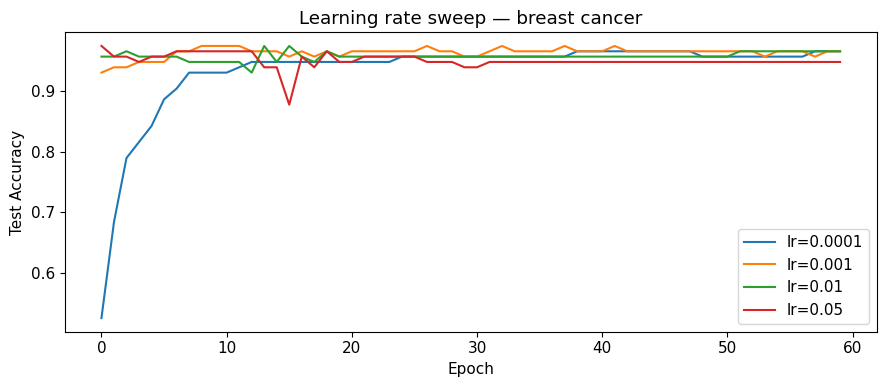

Tip: try learning rates on a log scale: 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, ...


In [28]:
# Quick learning rate sweep on breast cancer data
results = {}
for lr in [1e-4, 1e-3, 1e-2, 5e-2]:
    torch.manual_seed(42)
    m = CancerMLP(30, [64, 32], 2).to(device)
    h = train_model(m, train_loader, test_loader, n_epochs=60, lr=lr)
    results[lr] = h

plt.figure(figsize=(9, 4))
for lr, h in results.items():
    plt.plot(h['test_acc'], label=f'lr={lr}')
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.title('Learning rate sweep — breast cancer')
plt.legend()
plt.tight_layout()
plt.savefig('lr_sweep.png', dpi=100)
plt.show()
print('Tip: try learning rates on a log scale: 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, ...')

---
## Part 6 — Fine-tuning Pre-trained Models

In medicine, annotated data is **scarce and expensive**. Pre-trained models (trained on millions of natural images) already know how to detect edges, textures, and shapes — a head-start that makes a big difference with limited data.

### Transfer Learning Strategy

1. Load a pre-trained model (e.g., ResNet18 trained on ImageNet)
2. **Replace the final layer** with one matching your task (e.g., 2 classes)
3. **Freeze early layers** (they detect low-level features already)
4. **Fine-tune later layers** (they need to adapt to medical image domain)

```
[Frozen layers]   →  detect edges, textures, shapes (ImageNet knowledge)
[Trainable layers] → adapt to your medical task
[New head]         → your specific classes (malignant / benign / ...)
```

In [29]:
import torchvision.models as models

def build_finetuned_resnet(n_classes=2, freeze_backbone=True):
    """
    Load pretrained ResNet18, replace the final FC layer for our task.
    freeze_backbone=True: only train the new head (faster, fewer parameters)
    freeze_backbone=False: fine-tune the whole network (better with enough data)
    """
    model = models.resnet18(weights='IMAGENET1K_V1')   # download pretrained weights

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False   # freeze ALL parameters

    # Replace the final linear layer (512 → n_classes)
    model.fc = nn.Linear(512, n_classes)  # this layer is always trainable

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,} / Total: {total:,}  ({100*trainable/total:.1f}%)')
    return model


print('--- Frozen backbone (only train head) ---')
ft_model = build_finetuned_resnet(n_classes=2, freeze_backbone=True)

print('\n--- Full fine-tuning ---')
ft_full  = build_finetuned_resnet(n_classes=2, freeze_backbone=False)

--- Frozen backbone (only train head) ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Trainable: 1,026 / Total: 11,177,538  (0.0%)

--- Full fine-tuning ---
Trainable: 11,177,538 / Total: 11,177,538  (100.0%)


In [30]:
# ResNet18 expects 3-channel 224×224 images
# Our cell images are 1-channel 32×32 — adapt them

from torchvision import transforms

class CellDatasetForResNet(Dataset):
    """Resize and convert grayscale to 3-channel for ResNet."""
    def __init__(self, images, labels):
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(224),
            transforms.Grayscale(3),   # repeat channel 3 times
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet stats
                                  [0.229, 0.224, 0.225]),
        ])
        self.images = images  # numpy (N, 1, 32, 32) float32
        self.labels = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        img_uint8 = (self.images[i, 0] * 255).astype(np.uint8)  # (32, 32)
        return self.transform(img_uint8), int(self.labels[i])


n_img = len(labels)
n_tr  = int(0.8 * n_img)
img_train, img_test   = images[:n_tr], images[n_tr:]
lbl_train, lbl_test   = labels[:n_tr], labels[n_tr:]

ft_train_ds = CellDatasetForResNet(img_train, lbl_train)
ft_test_ds  = CellDatasetForResNet(img_test,  lbl_test)
ft_train_loader = DataLoader(ft_train_ds, batch_size=16, shuffle=True)
ft_test_loader  = DataLoader(ft_test_ds,  batch_size=16)

# Verify shape
X_b, y_b = next(iter(ft_train_loader))
print(f'Batch shape for ResNet18: {X_b.shape}  (batch, 3, 224, 224)')

Batch shape for ResNet18: torch.Size([16, 3, 224, 224])  (batch, 3, 224, 224)


Trainable: 1,026 / Total: 11,177,538  (0.0%)


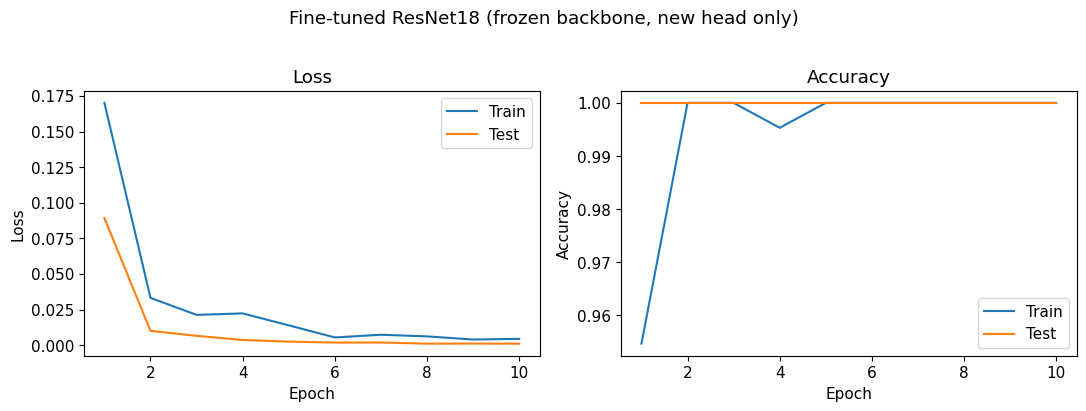

Fine-tuned test accuracy: 100.0%  in 10 epochs!


In [31]:
# Train only the head — fast even on CPU
torch.manual_seed(42)
ft_model = build_finetuned_resnet(n_classes=2, freeze_backbone=True).to(device)
history_ft = train_model(ft_model, ft_train_loader, ft_test_loader,
                         n_epochs=10, lr=1e-3)
plot_history(history_ft, 'Fine-tuned ResNet18 (frozen backbone, new head only)')
print(f'Fine-tuned test accuracy: {history_ft["test_acc"][-1]*100:.1f}%  in 10 epochs!')

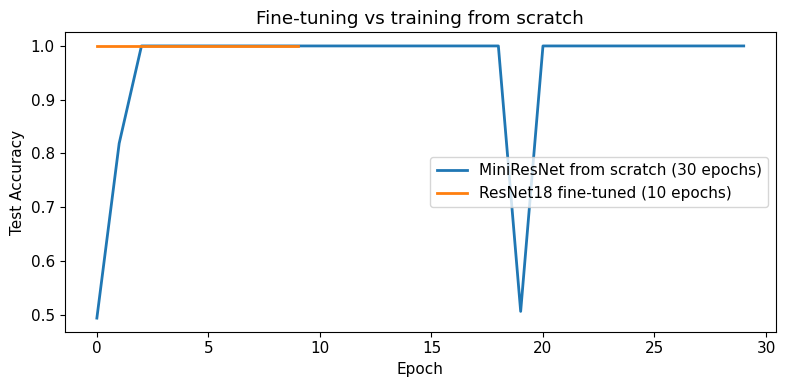

Fine-tuning reaches good accuracy in far fewer epochs.


In [32]:
# Compare: from-scratch mini ResNet vs fine-tuned ResNet18
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_resnet['test_acc'], label='MiniResNet from scratch (30 epochs)', linewidth=2)
ax.plot(history_ft['test_acc'],     label='ResNet18 fine-tuned (10 epochs)',     linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy')
ax.set_title('Fine-tuning vs training from scratch')
ax.legend()
plt.tight_layout()
plt.savefig('finetuning.png', dpi=100)
plt.show()
print('Fine-tuning reaches good accuracy in far fewer epochs.')

---
## Summary

| Concept | Key idea | Biomedical relevance |
|---|---|---|
| **Activation functions** | Introduce non-linearity; ReLU dominates | Enables complex pattern recognition |
| **Cross-entropy loss** | Measures prediction quality; expects logits | Standard for classification tasks |
| **Dropout** | Random neuron zeroing → prevents co-adaptation | Critical for small medical datasets |
| **Batch Normalization** | Normalizes activations per batch | Stabilizes training of deep networks |
| **CNN** | Shared filters exploit spatial structure | Natural choice for histology, radiology |
| **ResNet** | Skip connections → train very deep nets | Foundation of most medical imaging models |
| **Fine-tuning** | Reuse ImageNet knowledge, adapt to new task | Best strategy when labeled data is scarce |

### Key pitfalls to avoid

1. **CrossEntropyLoss**: pass raw logits, not softmax outputs
2. **zero_grad()**: call before every `loss.backward()`
3. **train/eval mode**: always switch with `model.train()` / `model.eval()`
4. **Learning rate**: most important hyperparameter — sweep on a log scale first
5. **Sanity check**: verify you can overfit a tiny batch before scaling up

---
## Exercises

1. **Dropout strength**: In Part 2, try dropout rates of 0.1, 0.3, 0.5, 0.7 on the 80-sample dataset. How does test accuracy change?

2. **Deeper CNN**: Add a 4th convolutional block to `CellCNN`. Does it improve accuracy? What if you remove BatchNorm?

3. **Data augmentation**: Add random horizontal flips and small random noise to the cell image dataset. Re-train the CNN and compare.

4. **Full fine-tuning**: Change `freeze_backbone=False` in `build_finetuned_resnet`. Use a smaller learning rate (1e-4). Does performance improve?

5. **Misclassified samples**: After training the CNN, find the test samples with the highest loss. Visualize them — what makes them hard to classify?